This fourth notebook allows us to bin our galaxy 3d unbinned cube into a new 3d cube. The bin size is the pixel count chosen to be used. 

To use, run the first two cells, then create a similar output as the examples after the Spatial Binning function cell. 

In general, you just need to copy a few lines from the galaxy cell input we've been using in each previous notebook and the single Spatial Binning function line. 

In [2]:
#These are the python packages that are needed for the full code. If you get an error, that means some package
#must be installed on python

from astropy.io import fits
import astropy
import matplotlib.pyplot as plt
import numpy as np
import datetime
import glob
from scipy.optimize import curve_fit
from numpy import loadtxt
from matplotlib.backends.backend_pdf import PdfPages
from astropy import units as u
from astropy.io.fits import Header
import os
import astropy.stats as ap
from astropy.io import fits
from astropy.modeling import models, fitting
from astropy.modeling.models import custom_model
from astropy.modeling import Fittable1DModel, Parameter
import pandas as pd
import matplotlib.pyplot as plt
from scipy import interpolate
import numpy as np
import math
import numpy.polynomial.polynomial as poly
import fnmatch

To calculate the kpc scale of our galaxies, I used Ned Wright's cosmology calculator to figure out the kpc/pixel scale in the excel sheet the function below references.

Link to calculator: https://www.astro.ucla.edu/~wright/CosmoCalc.html

Here are the cosmological constants I used for the excel sheet:

H0 = 70 km/s

Omega_m = 0.3

Omega_lambda = 0.7

In [4]:
#Spatial binning code so that we specify a galaxy and how many pixels we want to bin, then get a binned
# 3D data cube, similar to the output from the v3.5 data reduction notebook

def SpatialBinning(path, galaxy_name, binned_pixels, date, date_link, setting):
    #load in cube to bin
    frame = fits.open(path + "3D Output Cubes Unbinned/" + galaxy_name + "_major_Cube.fits")
    
    #Load in kpc scale
    data_frame = pd.read_excel(path + 'Binning Work/Information on Binned Pixel and Spatial Scales.xlsx')
    index = data_frame[data_frame['SDSS Name'] == galaxy_name].index
    index = index[0]
    kpc_scale = data_frame.at[index,'actual bin size (kpc)']
    print(kpc_scale)
    
    #Load in galaxy info
    df = pd.read_excel(path + 'Galaxy Properties/Extended Galaxy information.xlsx')
    ind = df[df['Galaxy'] == galaxy_name].index
    ind = ind[0]
    RA = df.at[ind,'RA']
    Dec = df.at[ind,'DEC']
    
    data = frame[0].data
    data = np.transpose(data[:,:,0])
    error = frame[1].data
    error = np.transpose(error[:,:,0])
    
    central_row = 141 
    plt.imshow(data)
    new_data=[]

    if (binned_pixels/2)==0:
        sky_zone_2 = round(central_row) - 20*binned_pixels - np.floor(binned_pixels/2)
        sky_zone_3 = round(central_row) + 20*binned_pixels + np.floor(binned_pixels/2) - 1
    else:
        sky_zone_2 = round(central_row) - 20*binned_pixels - np.floor(binned_pixels/2)
        sky_zone_3 = round(central_row) + 20*binned_pixels + np.floor(binned_pixels/2)
                       
    for columns in range(0,2042):
        sky_zone_2 = int(sky_zone_2)
        sky_zone_3 = int(sky_zone_3)
        new_data = data[sky_zone_2:sky_zone_3, :]
    
    print(new_data.shape)
    
    binned_data = np.array(new_data)
    plt.figure(figsize=(12,12))#
    plt.imshow(binned_data[:,:],origin="lower",cmap="gray",vmin=0) 
    plt.title(galaxy_name + " Trimmed Data" ,color="black")
    plt.xlabel('Wavelength (Angstrom)')
    plt.ylabel('Spatial Info (pixel)')
    if not os.path.exists(path + "Working Files/Binning/" + galaxy_name + "/Image Test/"):
        os.makedirs(path + "Working Files/Binning/" + galaxy_name + "/Image Test/")
    plt.savefig(path + "Working Files/Binning/" + galaxy_name + "/Image Test/" + galaxy_name + " [" + str(binned_pixels) + " Bin]" + ".pdf")
    plt.close()
    
    #Attempt to fit a gaussian to 1 emission line on master arc frame
    compound_model_bounded = models.Gaussian1D(3000, len(binned_data[:,0:1])/2, 25) + models.Polynomial1D(degree=1) 
    delta = 25
    compound_model_bounded.mean_0.max = len(binned_data[:,0:1])/2 + delta 
    compound_model_bounded.mean_0.min = len(binned_data[:,0:1])/2 - delta

    x_line_fit2 = np.linspace(1,len(binned_data[:,0:1]),len(binned_data[:,0:1]))
    y_line_fit2 = new_data[:,870:871]
    y_line_fit2 = y_line_fit2.reshape(-2)



    fitter = fitting.LevMarLSQFitter()
    compound_fit_bounded = fitter(compound_model_bounded, x_line_fit2,y_line_fit2)

    plt.figure(figsize=(8,5))
    plt.plot(x_line_fit2,y_line_fit2, color='k')
    plt.plot(x_line_fit2, compound_fit_bounded(x_line_fit2), color='darkorange')
    plt.title("Column 871 Fit from Flux Calibrated " + galaxy_name ,color="black")
    plt.xlabel('Pixel Row Number')
    plt.ylabel('Flux')
    
    if not os.path.exists(path + "Working Files/Binning/" + galaxy_name + "/Center Fit/"):
        os.makedirs(path + "Working Files/Binning/" + galaxy_name + "/Center Fit/")
    plt.savefig(path + "Working Files/Binning/" + galaxy_name + "/Center Fit/" + galaxy_name + " Central Fit [" + str(binned_pixels) + " Bin]" + ".pdf")
    plt.close()

    #Slice of binned data to check if binning worked from previous image
    newly_binned_data=[]
    for rows in range(0,len(y_line_fit2),binned_pixels):
        newly_binned_data.append(np.sum(new_data[rows:rows+binned_pixels,:][:],axis=0))

    binned_data = np.array(newly_binned_data)
    plt.figure(figsize=(18,18))
    plt.imshow(binned_data[:,:],origin="lower",cmap="gray",vmin=0) 
    plt.title(galaxy_name + " Binned Data" ,color="black")
    plt.xlabel('Wavelength (Angstrom)')
    plt.ylabel('Spatial Info (binned pixels)')
    print(binned_data.shape)
    plt.savefig(path + "Working Files/Binning/" + galaxy_name + "/Image Test/" + galaxy_name + " Binned " + str(binned_pixels) + " Bin" + ".pdf")
    plt.close()
    
    
    x_line_fit3 = np.linspace(1,round(len(binned_data[:,0:1])),round(len(binned_data[:,0:1])))
    y_line_fit3 = binned_data[:,870:871]
    y_line_fit3 = y_line_fit3.reshape(-2)
    
    
    #Attempt to fit a gaussian to 1 emission line on binned data to find the central row
    compound_model_bounded = models.Gaussian1D(max(y_line_fit3), len(binned_data[:,0:1])/2, 5) + models.Polynomial1D(degree=1) 
    delta = 5
    compound_model_bounded.mean_0.max = len(binned_data[:,0:1])/2 + delta 
    compound_model_bounded.mean_0.min = len(binned_data[:,0:1])/2 - delta

    


    fitter = fitting.LevMarLSQFitter()
    compound_fit_bounded = fitter(compound_model_bounded, x_line_fit3,y_line_fit3)
    plt.figure(figsize=(8,5))
    plt.plot(x_line_fit3,y_line_fit3, color='k')
    plt.plot(x_line_fit3, compound_fit_bounded(x_line_fit3), color='darkorange')
    plt.title("Column 870 Fit from Flux Calibrated " + galaxy_name ,color="black")
    plt.xlabel('Pixel Row Number')
    plt.ylabel('Added Flux')
    plt.savefig(path + "Working Files/Binning/" + galaxy_name + "/Center Fit/" + galaxy_name + " Binned Central Fit [" + str(binned_pixels) + " Bin]" + ".pdf")
    plt.close()
    
    #Now, replicate for error
    #Taking a slice of the trimmed error data
    for column in range((error.shape[1])):

        data_e = error[sky_zone_2:sky_zone_3, :]
        

    plt.figure(figsize=(12,12))
    plt.imshow(data_e[:,:],origin="lower",cmap="gray",vmin=0) 
    plt.title(galaxy_name + " Trimmed Error Data" ,color="black")
    plt.xlabel('Wavelength (Angstrom)')
    plt.ylabel('Spatial Info (pixel)')

    print(data_e.shape)
    plt.savefig(path + "Working Files/Binning/" + galaxy_name + "/Image Test/" + galaxy_name + " Error [" + str(binned_pixels) + " Bin]" + ".pdf")
    plt.close()
    
    
    #Binning error data 
    new_error = []
    #For all trimmed rows, in groups of [binned_pixels], add in quadrature that range of rows 
    #If binned_pixels = 5, then rows (0,1,2,3,4) are added in quadrature followed by rows (5,6,7,8,9), etc
    for rows in range(0,len(y_line_fit2),binned_pixels):
        error_array = np.asarray(data_e[rows:rows+binned_pixels,:][:])
        #error prop should just be variance 1 + variance 2. . . 
        quadrature = sum(i for i in error_array)
        new_error.append(quadrature)
    binned_error_d = np.array(new_error)

    #Image slice of binned error:
    plt.figure(figsize=(18,18))
    plt.imshow(binned_error_d[:,:],origin="lower",cmap="gray",vmin=0) 
    plt.title(galaxy_name + " Binned Error Data" ,color="black")
    plt.xlabel('Wavelength (Angstrom)')
    print(binned_error_d.shape)
    
    plt.savefig(path + "Working Files/Binning/" + galaxy_name + "/Image Test/" + galaxy_name + " Error Binned [" + str(binned_pixels) + " Bin]" + ".pdf")
    plt.close()
    
    base_data = binned_data
    base_error = binned_error_d
    
    base_data =base_data.astype(np.float32)
    base_error = base_error.astype(np.float32)

    transposed = np.transpose(base_data)
    transposed_error = np.transpose(base_error)


    reshaped_data = transposed.reshape(base_data.shape[1], base_data.shape[0],1 ) 
    reshaped_data = reshaped_data.astype(np.float32)
    #[HERE]  the following line is what I think is making negative and 0 points be larger than 0
    #reshaped_data [reshaped_data <= 0] = 1

    double = np.repeat(reshaped_data,2,-1)
    reshaped_error = transposed_error.reshape(base_error.shape[1], base_error.shape[0],1 ) 
    reshaped_error = reshaped_error.astype(np.float32)
    #[HERE]  the following line is what I think is making negative and 0 points be larger than 0
    #reshaped_error [reshaped_error <= 0] = .000000001
    double_error = np.repeat(reshaped_error,2,-1)
    
    #bad pixel map creation for LZIFU (Extension 2)

    bad_pixel_map = double_error * 0
    
    #Writing to temporary file
    empty_hdu = fits.Header()
    empty_primary = fits.PrimaryHDU(header=empty_hdu)

    spectrum_hdu = fits.ImageHDU(double)

    error_hdu = fits.ImageHDU(double_error)

    bpm_hdu = fits.ImageHDU(bad_pixel_map)

    data_cube = fits.HDUList([empty_primary,spectrum_hdu,error_hdu,bpm_hdu])

    print(data_cube[1].shape)


    if not os.path.exists(path + "Working Files/Binning/" + galaxy_name + "/Temp/"):
        os.makedirs(path + "Working Files/Binning/" + galaxy_name + "/Temp/")
    

    data_cube.writeto(path + "Working Files/Binning/" + galaxy_name + "/Temp/Temp_Cube_Binned_" + galaxy_name +".fits",overwrite=True)

    
    #Change file path when needed
    cube = fits.open(path + "Working Files/Binning/" + galaxy_name + "/Temp/Temp_Cube_Binned_" + galaxy_name +".fits")
    cube.info()
    cube[1].shape
    cube.close()
    
    
    #Plotting Pixel column to wavelength column
    #Change file path and specify which wavelength-pixel text file to use
    pixel = np.loadtxt(path + 'Observations/Wav_'+ date +'-2_'+setting+'.txt', comments="#",delimiter="	")
    x = pixel[:,1]
    y = pixel[:,0]
    p = np.polyfit(x, y, 1)
    print('1D polyfit function coefficients:',p)

    xaxis= np.linspace(0,2042,num=2042)
    yaxis= np.polyval([p[0],p[1]],xaxis)

    #R squared calculation:
    diff = y-y.mean()
    squarediff= diff**2
    SST= squarediff.sum()
    difff= np.polyval([p[0],p[1]],x)-y.mean()
    squaredihat=difff**2
    SSE=squaredihat.sum()

    Rsquared=SSE/SST
    
    galaxy_cont = binned_data

    test0 = cube[0].header
    test0.set('OBJECT', galaxy_name + ' (DATA)')
    test0.set('BUNIT','10**(20)*erg/s/cm**2/Angstrom')
    test0.set('CRPIX1',round(compound_fit_bounded.parameters[1],0))
    test0['CRPIX1'] = (round(compound_fit_bounded.parameters[1],0),'Center of galaxy')
    test0.set('CRPIX2',round(compound_fit_bounded.parameters[1],0))
    test0['CRPIX2'] = (round(compound_fit_bounded.parameters[1],0),'Center of galaxy')
    test0.set('CUNIT1','deg     ')
    test0.set('CUNIT2','deg     ')
    test0.set('CTYPE1','RA---TAN')
    test0.set('CTYPE2','DEC--TAN')
    test0.set('CRVAL1',RA)
    test0.set('CDELT1',-9.4444444*10**(-5)* binned_pixels)
    test0['CDELT1'] = (-9.4444444*10**(-5)* binned_pixels,'Spatial scale in degrees per pixel')
    test0.set('CRVAL2',Dec)
    test0.set('CDELT2 ', 9.4444444*10**(-5)* binned_pixels)
    test0['CDELT2'] = (9.4444444*10**(-5)* binned_pixels,'Spatial scale in degrees per pixel')
    test0.set('CTYPE3','AWAV    ')
    test0.set('CUNIT3','Angstrom')
    test0.set('CRPIX3',1.)
    test0.set('CRVAL3', np.polyval([p[0],p[1]],2041))
    test0['CRVAL3'] = (np.polyval([p[0],p[1]],2041),'Starting wavelength value')
    test0.set('CDELT3',round(np.abs(p[0]),8))
    test0['CDELT3'] = (round(np.abs(p[0]),8),'Wavelength scale in Angstrom per pixel')
    print(repr(test0))
    test0.set('BINSARCS',0.34)
    test0.set('BINKPC',kpc_scale * binned_pixels)
    print(repr(test0))

    test = cube[1].header
    test.set('EXTNAME','DATA  ')
    
    test2 = cube[2].header
    test2.set('EXTNAME','ERROR  ')
    print(repr(test2))
    
    test3 = cube[3].header
    test3.set('EXTNAME','Bad Pixel Map')
    
    
    empty_hdu = fits.Header()
    empty_primary = fits.PrimaryHDU(header=empty_hdu)

    spectrum_hdu = fits.PrimaryHDU(double)

    error_hdu = fits.ImageHDU(double_error)


    bpm_hdu = fits.ImageHDU(bad_pixel_map)

    data_cube = fits.HDUList([spectrum_hdu,error_hdu,bpm_hdu])

    print(data_cube[1].shape)

    data_cube[0].header = test0
    data_cube[1].header = test2
    data_cube[2].header = test3

    #Change file path when needed
    data_cube.writeto(path + "Binned 3D Output Cubes/" + galaxy_name + "_major_Cube_"+str(binned_pixels) + "_Bin.fits",overwrite=True)
    trial = fits.open(path + "Binned 3D Output Cubes/" + galaxy_name + "_major_Cube_"+str(binned_pixels) + "_Bin.fits")

In [5]:
#Spatial Binning example
#path = "/Users/Toni/Desktop/Remote Work/LDT-Pipeline/"#This is the file path to the main reduction
#galaxy_name = "J1703+2531_minor" #Using our observing logs, this is the galaxy's name that we want to reduce
#galaxy_name_2 = "J1703+2531"  
#date = "8-22" 
#date_link = "Aug 22 2019" 
#setting = "A" 
#SpatialBinning(path, galaxy_name_2, 5, date, date_link, setting)

/opt/anaconda3/lib/python3.11/site-packages/openpyxl/worksheet/_read_only.py:79: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


0.27914
(204, 2042)
(41, 2042)
(204, 2042)
(41, 2042)
(2042, 41, 2)
Filename: /Users/spogs/Documents/TypeIt_Data_Reduction_Pipeline/Working Files/Binning/J0800+3743/Temp/Temp_Cube_Binned_J0800+3743.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 ImageHDU         8   (2, 41, 2042)   float32   
  2                1 ImageHDU         8   (2, 41, 2042)   float32   
  3                1 ImageHDU         8   (2, 41, 2042)   float32   
1D polyfit function coefficients: [-1.33812451e+00  7.27014291e+03]
SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
OBJECT  = 'J0800+3743 (DATA)'                                                   
BUNI

/opt/anaconda3/lib/python3.11/site-packages/openpyxl/worksheet/_read_only.py:79: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


(41, 2042)
(2042, 41, 2)
Filename: /Users/spogs/Documents/TypeIt_Data_Reduction_Pipeline/Working Files/Binning/J0800+3743/Temp/Temp_Cube_Binned_J0800+3743.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 ImageHDU         8   (2, 41, 2042)   float32   
  2                1 ImageHDU         8   (2, 41, 2042)   float32   
  3                1 ImageHDU         8   (2, 41, 2042)   float32   
1D polyfit function coefficients: [-1.33812451e+00  7.27014291e+03]
SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
OBJECT  = 'J0800+3743 (DATA)'                                                   
BUNIT   = '10**(20)*erg/s/cm**2/Angstrom'      

/opt/anaconda3/lib/python3.11/site-packages/openpyxl/worksheet/_read_only.py:79: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


(122, 2042)
(41, 2042)
(2042, 41, 2)
Filename: /Users/spogs/Documents/TypeIt_Data_Reduction_Pipeline/Working Files/Binning/J0800+3743/Temp/Temp_Cube_Binned_J0800+3743.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 ImageHDU         8   (2, 41, 2042)   float32   
  2                1 ImageHDU         8   (2, 41, 2042)   float32   
  3                1 ImageHDU         8   (2, 41, 2042)   float32   
1D polyfit function coefficients: [-1.33812451e+00  7.27014291e+03]
SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
OBJECT  = 'J0800+3743 (DATA)'                                                   
BUNIT   = '10**(20)*erg/s/cm**2/Ang

/opt/anaconda3/lib/python3.11/site-packages/openpyxl/worksheet/_read_only.py:79: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


(41, 2042)
(2042, 41, 2)
Filename: /Users/spogs/Documents/TypeIt_Data_Reduction_Pipeline/Working Files/Binning/J0800+3743/Temp/Temp_Cube_Binned_J0800+3743.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 ImageHDU         8   (2, 41, 2042)   float32   
  2                1 ImageHDU         8   (2, 41, 2042)   float32   
  3                1 ImageHDU         8   (2, 41, 2042)   float32   
1D polyfit function coefficients: [-1.33812451e+00  7.27014291e+03]
SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
OBJECT  = 'J0800+3743 (DATA)'                                                   
BUNIT   = '10**(20)*erg/s/cm**2/Angstrom'      

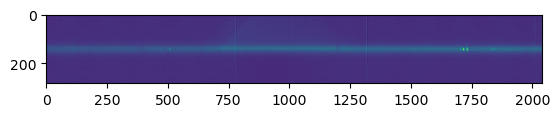

In [6]:
#Spatial Binning example

#In this cell, we will be changing the inputs required throughout the rest of the pipeline
path = "/Users/spogs/Documents/TypeIt_Data_Reduction_Pipeline/"#This is the file path to the main reduction
galaxy_name = "J0800+3743_major" #Using our observing logs, this is the galaxy's name that we want to reduce
galaxy_name_2 = "J0800+3743"
galaxy_file_name = galaxy_name #Same as last line (Artifact of a past code that needed 2)
standard_star_name = "HR3454" #Standard star name (Also observed right before/after our galaxy)
date = "2-16" #observation date as a number
date_link = "Feb 16 2020" # observation date
RA = 120.1986 #galaxy's RA value from SPOGs catalog
Dec = 37.7287 #galaxy's Dec value from SPOGs catalog
setting = "A" #Should be an A or B. This refers to the wavelength range observed.






SpatialBinning(path, galaxy_name_2, 5, date, date_link, setting)
SpatialBinning(path, galaxy_name_2, 4, date, date_link, setting)
SpatialBinning(path, galaxy_name_2, 3, date, date_link, setting)
SpatialBinning(path, galaxy_name_2, 2, date, date_link, setting)